# Нейронная сеть для распознавания крестиков и ноликов

Задание: обучить нейронную сеть, распознающую две категории изображений: крестики (X) и нолики (O), с точностью более 95%.

In [1]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

print('Все библиотеки успешно подключены!')

Все библиотеки успешно подключены!


In [2]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [4]:
# Распаковываем архив hw_pro.zip в папку hw_pro
!unzip -q hw_pro.zip

In [6]:
# Путь к директории с базой
base_dir = 'hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                          target_size=(img_height, img_width),
                                                          color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в питру-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (102, 20, 20, 1)
Размер массива y_train (102,)


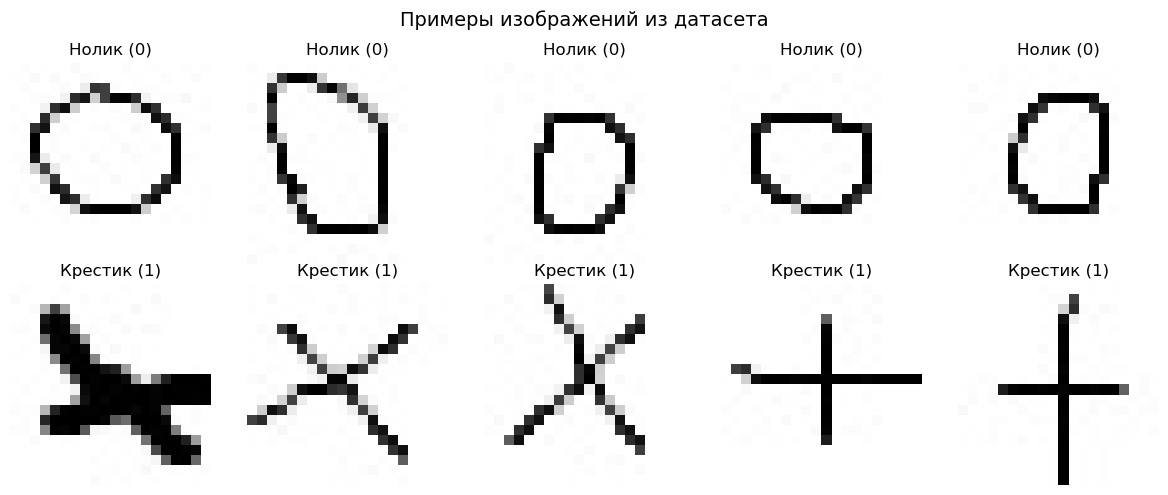

In [7]:
# Просмотр примеров из датасета
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Примеры изображений из датасета', fontsize=14)

# Нолики (класс 0)
zeros_idx = np.where(y_train == 0)[0][:5]
for i, idx in enumerate(zeros_idx):
    axes[0, i].imshow(x_train[idx].reshape(img_height, img_width), cmap='gray')
    axes[0, i].set_title('Нолик (0)')
    axes[0, i].axis('off')

# Крестики (класс 1)
ones_idx = np.where(y_train == 1)[0][:5]
for i, idx in enumerate(ones_idx):
    axes[1, i].imshow(x_train[idx].reshape(img_height, img_width), cmap='gray')
    axes[1, i].set_title('Крестик (1)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Нормализация данных (приведение значений пикселей к диапазону [0, 1])
x_train = x_train / 255.0

# Преобразование меток в формат one-hot encoding
y_train_cat = utils.to_categorical(y_train, 2)

print('Размер x_train после нормализации:', x_train.shape)
print('Размер y_train_cat после to_categorical:', y_train_cat.shape)
print('Пример метки (one-hot):', y_train_cat[0])

Размер x_train после нормализации: (102, 20, 20, 1)
Размер y_train_cat после to_categorical: (102, 2)
Пример метки (one-hot): [1. 0.]


In [9]:
from sklearn.model_selection import train_test_split

# Разделение на обучающую и тестовую выборки (80% / 20%)
x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
    x_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

print('Обучающая выборка:', x_train_split.shape)
print('Тестовая выборка:', x_test_split.shape)

Обучающая выборка: (81, 20, 20, 1)
Тестовая выборка: (21, 20, 20, 1)


In [10]:
# Создание нейронной сети с использованием сверточных слоев (CNN)
# CNN отлично подходит для задач классификации изображений

model = Sequential([
    # Первый сверточный блок
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Второй сверточный блок
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Третий сверточный блок
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    
    # Преобразование в одномерный вектор
    Flatten(),
    
    # Полносвязные слои
    Dense(256, activation='relu'),
    Dropout(0.4),  # Регуляризация для предотвращения переобучения
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    # Выходной слой (2 класса: нолик и крестик)
    Dense(2, activation='softmax')
])

# Вывод архитектуры сети
model.summary()

F:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 20, 20, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 20, 20, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 10, 10, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 10, 10, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 5, 5, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 5, 5, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 946,178 (3.61 MB)

 Trainable params: 945,730 (3.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Компиляция модели
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Оптимизатор Adam
    loss='categorical_crossentropy',       # Функция потерь для многоклассовой классификации
    metrics=['accuracy']                   # Метрика точности
)

print('Модель успешно скомпилирована!')

Модель успешно скомпилирована!


In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks для улучшения обучения
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Обучение модели
history = model.fit(
    x_train_split, y_train_split,
    epochs=50,
    batch_size=16,
    validation_data=(x_test_split, y_test_split),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7901 - loss: 0.4646 - val_accuracy: 0.4762 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9877 - loss: 0.0239 - val_accuracy: 0.4762 - val_loss: 0.6249 - learning_rate: 0.0010
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 8.1530e-04 - val_accuracy: 0.5238 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.4762 - val_loss: 0.5967 - learning_rate: 0.0010
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 1.5929e-04 - val_accuracy: 0.4762 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 2.0785e-04 - val_accuracy: 0.4762 - val_loss: 0.7003 - learning_rate: 0.0010
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accur

In [13]:
# Оценка качества модели на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test_split, y_test_split, verbose=0)
print(f'Точность на тестовой выборке: {test_accuracy * 100:.2f}%')
print(f'Потери на тестовой выборке: {test_loss:.4f}')

if test_accuracy >= 0.95:
    print('\n✅ Цель достигнута! Точность более 95%!')
else:
    print('\n⚠️ Точность ниже 95%. Требуется дополнительная настройка.')

Точность на тестовой выборке: 100.00%
Потери на тестовой выборке: 0.4772

✅ Цель достигнута! Точность более 95%!


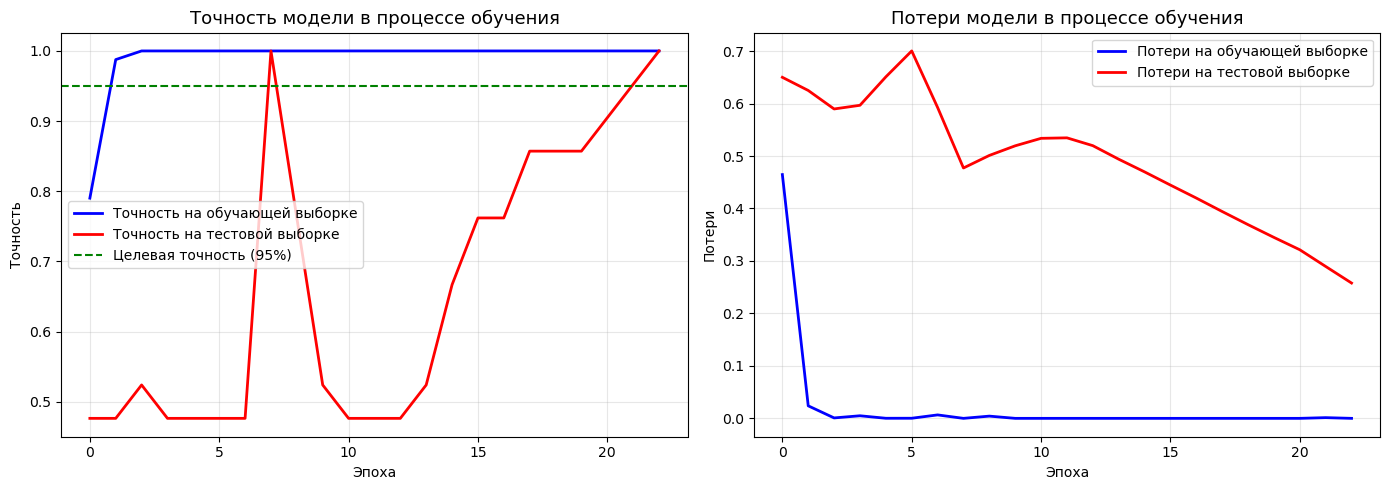

In [14]:
# Визуализация процесса обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График точности
ax1.plot(history.history['accuracy'], label='Точность на обучающей выборке', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Точность на тестовой выборке', color='red', linewidth=2)
ax1.axhline(y=0.95, color='green', linestyle='--', label='Целевая точность (95%)')
ax1.set_title('Точность модели в процессе обучения', fontsize=13)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График потерь
ax2.plot(history.history['loss'], label='Потери на обучающей выборке', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Потери на тестовой выборке', color='red', linewidth=2)
ax2.set_title('Потери модели в процессе обучения', fontsize=13)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


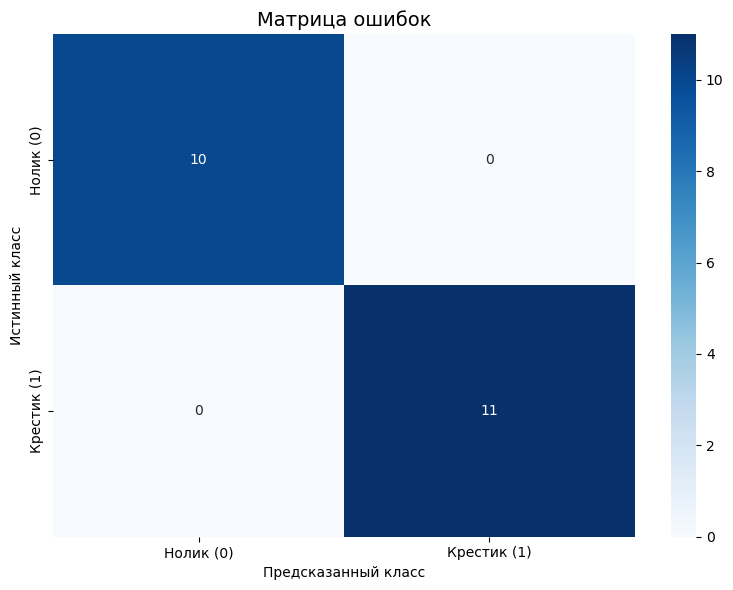


Подробный отчёт по классификации:
              precision    recall  f1-score   support

   Нолик (0)       1.00      1.00      1.00        10
 Крестик (1)       1.00      1.00      1.00        11

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Предсказания на тестовой выборке
y_pred = model.predict(x_test_split)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_split, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нолик (0)', 'Крестик (1)'],
            yticklabels=['Нолик (0)', 'Крестик (1)'])
plt.title('Матрица ошибок', fontsize=14)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Отчёт по классификации
print('\nПодробный отчёт по классификации:')
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=['Нолик (0)', 'Крестик (1)']))

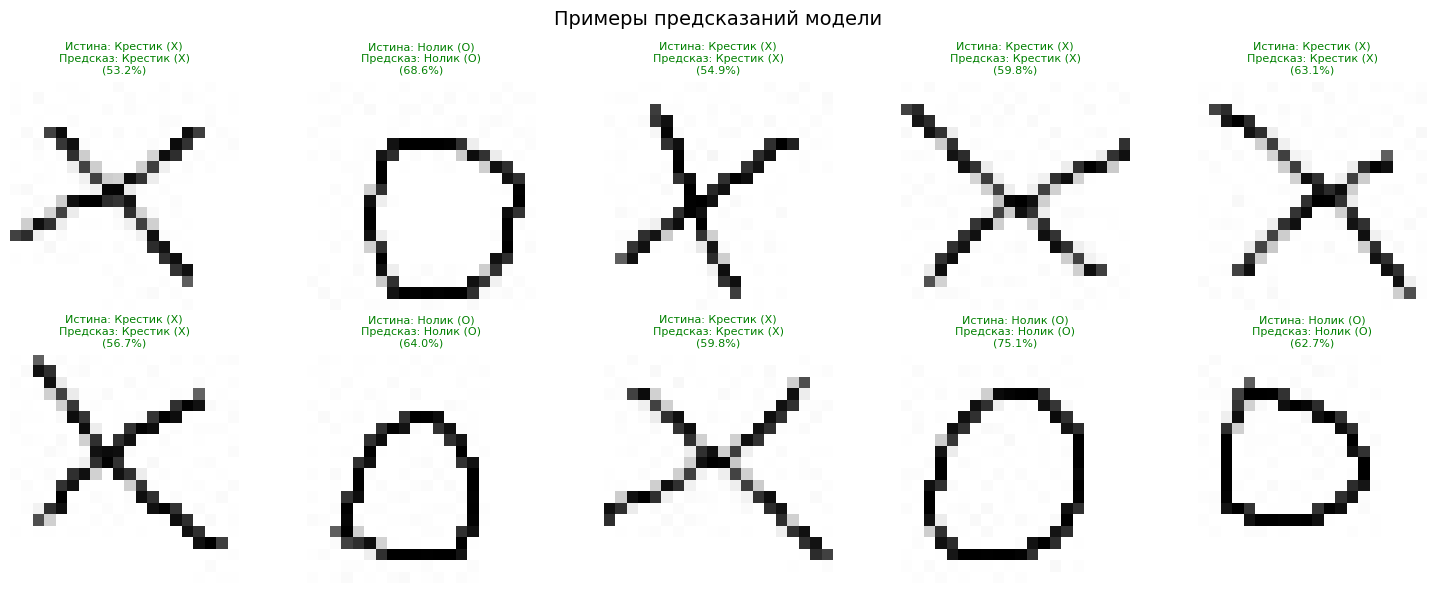

In [16]:
# Визуализация предсказаний на примерах из тестовой выборки
class_names = ['Нолик (O)', 'Крестик (X)']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Примеры предсказаний модели', fontsize=14)

for i in range(10):
    ax = axes[i // 5, i % 5]
    img = x_test_split[i].reshape(img_height, img_width)
    true_label = class_names[y_true_classes[i]]
    pred_label = class_names[y_pred_classes[i]]
    confidence = np.max(y_pred[i]) * 100
    
    ax.imshow(img, cmap='gray')
    
    color = 'green' if y_true_classes[i] == y_pred_classes[i] else 'red'
    ax.set_title(f'Истина: {true_label}\nПредсказ: {pred_label}\n({confidence:.1f}%)',
                 color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Функция для предсказания нового изображения
def predict_image(img_path):
    """Предсказывает класс изображения (крестик или нолик)"""
    img = image.load_img(img_path, target_size=(img_height, img_width), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Добавляем batch dimension
    
    prediction = model.predict(img_array, verbose=0)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx] * 100
    
    class_names = {0: 'Нолик (O)', 1: 'Крестик (X)'}
    
    # Отображение изображения
    plt.figure(figsize=(4, 4))
    plt.imshow(image.img_to_array(img).reshape(img_height, img_width), cmap='gray')
    plt.title(f'Предсказание: {class_names[class_idx]}\nУверенность: {confidence:.1f}%', fontsize=12)
    plt.axis('off')
    plt.show()
    
    return class_names[class_idx], confidence

print('Функция predict_image готова к использованию!')
print('Пример использования: predict_image(\'path/to/image.png\')')

Функция predict_image готова к использованию!
Пример использования: predict_image('path/to/image.png')


In [18]:
# Итоговый результат
print('=' * 50)
print('           ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
print('=' * 50)
print(f'Точность на тестовой выборке: {test_accuracy * 100:.2f}%')
print(f'Потери на тестовой выборке:   {test_loss:.4f}')
print('=' * 50)

if test_accuracy >= 0.95:
    print('✅ ЗАДАНИЕ ВЫПОЛНЕНО! Точность > 95%')
else:
    print('❌ Точность ниже целевого значения 95%')
print('=' * 50)

           ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Точность на тестовой выборке: 100.00%
Потери на тестовой выборке:   0.4772
✅ ЗАДАНИЕ ВЫПОЛНЕНО! Точность > 95%
